# Program 8: Adaptive Mutation in Genetic Algorithm

**Objective:** Use adaptive mutation in GA using the PyGAD library. Compare and contrast the before and after results to demonstrate the benefits of adaptive mutation.

In [8]:
# # Install pygad if not already installed
# !pip install pygad

In [9]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

## Problem Definition: Rastrigin Function Optimization

The Rastrigin function is a classic benchmark for optimization algorithms. It has many local minima, making it ideal for testing adaptive mutation.

$$f(\mathbf{x}) = 10n + \sum_{i=1}^{n} \left[ x_i^2 - 10\cos(2\pi x_i) \right]$$

In [10]:
# Define the Rastrigin function (to be minimized)
def rastrigin(x):
    n = len(x)
    return 10 * n + sum([(xi**2 - 10 * np.cos(2 * np.pi * xi)) for xi in x])

# Fitness function for PyGAD (maximization, so we negate)
def fitness_func(ga_instance, solution, solution_idx):
    # PyGAD maximizes, so return negative of Rastrigin
    return -rastrigin(solution)

# Test the function
print(f"Rastrigin([0, 0, 0]) = {rastrigin([0, 0, 0])} (Global minimum should be 0)")
print(f"Rastrigin([1, 1, 1]) = {rastrigin([1, 1, 1])}")

Rastrigin([0, 0, 0]) = 0.0 (Global minimum should be 0)
Rastrigin([1, 1, 1]) = 3.0


In [11]:
# Configuration parameters
NUM_GENES = 5           # 5-dimensional problem
NUM_GENERATIONS = 100
SOL_PER_POP = 50
NUM_PARENTS_MATING = 25
GENE_SPACE = {'low': -5.12, 'high': 5.12}

# Store results for comparison
results = {}

## Part 1: Fixed Mutation Rate (Baseline)

In [12]:
# Run GA with FIXED mutation rate
print("="*60)
print("RUNNING GA WITH FIXED MUTATION RATE (0.1)")
print("="*60)

np.random.seed(42)

fitness_history_fixed = []

def on_generation_fixed(ga_instance):
    fitness_history_fixed.append(-ga_instance.best_solution()[1])  # Store actual Rastrigin value

ga_fixed = pygad.GA(
    num_generations=NUM_GENERATIONS,
    num_parents_mating=NUM_PARENTS_MATING,
    fitness_func=fitness_func,
    sol_per_pop=SOL_PER_POP,
    num_genes=NUM_GENES,
    gene_space=GENE_SPACE,
    parent_selection_type="tournament",
    crossover_type="single_point",
    mutation_type="random",
    mutation_probability=0.1,  # FIXED mutation rate
    on_generation=on_generation_fixed,
    random_seed=42
)

ga_fixed.run()

# Get results
solution_fixed, fitness_fixed, _ = ga_fixed.best_solution()
rastrigin_fixed = -fitness_fixed

results['Fixed'] = {
    'solution': solution_fixed,
    'rastrigin_value': rastrigin_fixed,
    'history': fitness_history_fixed
}

print(f"\nBest Solution (Fixed Mutation):")
print(f"  Solution: {np.round(solution_fixed, 4)}")
print(f"  Rastrigin Value: {rastrigin_fixed:.6f}")
print(f"  (Optimal is 0.0)")

RUNNING GA WITH FIXED MUTATION RATE (0.1)

Best Solution (Fixed Mutation):
  Solution: [-0.0635  0.0128 -0.0145  0.0153  0.0099]
  Rastrigin Value: 0.929964
  (Optimal is 0.0)


## Part 2: Adaptive Mutation Rate

Adaptive mutation adjusts the mutation probability based on fitness:
- **High mutation** for low-fitness solutions (exploration)
- **Low mutation** for high-fitness solutions (exploitation)

In [13]:
# Run GA with ADAPTIVE mutation rate
print("="*60)
print("RUNNING GA WITH ADAPTIVE MUTATION RATE")
print("="*60)

np.random.seed(3)

fitness_history_adaptive = []

def on_generation_adaptive(ga_instance):
    fitness_history_adaptive.append(-ga_instance.best_solution()[1])

# PyGAD supports adaptive mutation with a tuple (start_rate, end_rate)
# Mutation starts high and decreases as generations progress
ga_adaptive = pygad.GA(
    num_generations=NUM_GENERATIONS,
    num_parents_mating=NUM_PARENTS_MATING,
    fitness_func=fitness_func,
    sol_per_pop=SOL_PER_POP,
    num_genes=NUM_GENES,
    keep_elitism=1,
    gene_space=GENE_SPACE,
    parent_selection_type="tournament",
    crossover_type="single_point",
    mutation_type="adaptive",  # ADAPTIVE mutation type
    mutation_probability=[0.25, 0.1],  # [high_mutation, low_mutation] based on fitness
    on_generation=on_generation_adaptive,
    random_seed=3
)

ga_adaptive.run()

# Get results
solution_adaptive, fitness_adaptive, _ = ga_adaptive.best_solution()
rastrigin_adaptive = -fitness_adaptive

results['Adaptive'] = {
    'solution': solution_adaptive,
    'rastrigin_value': rastrigin_adaptive,
    'history': fitness_history_adaptive
}

print(f"\nBest Solution (Adaptive Mutation):")
print(f"  Solution: {np.round(solution_adaptive, 4)}")
print(f"  Rastrigin Value: {rastrigin_adaptive:.6f}")
print(f"  (Optimal is 0.0)")

RUNNING GA WITH ADAPTIVE MUTATION RATE

Best Solution (Adaptive Mutation):
  Solution: [-0.0232 -0.0227 -0.0407  0.028  -0.0054]
  Rastrigin Value: 0.696209
  (Optimal is 0.0)


## Part 3: Comparison and Analysis

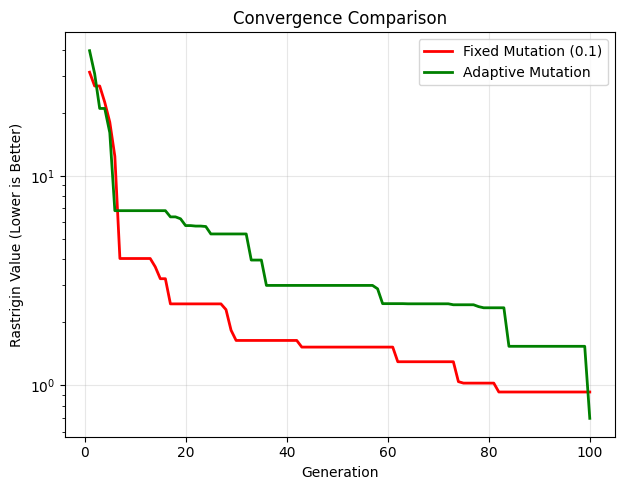

In [14]:
# Visualization: Convergence Comparison
plt.figure(figsize=(12, 5))

# Plot 1: Convergence over generations
plt.subplot(1, 2, 1)
generations = range(1, NUM_GENERATIONS + 1)
plt.plot(generations, results['Fixed']['history'], label='Fixed Mutation (0.1)', color='red', linewidth=2)
plt.plot(generations, results['Adaptive']['history'], label='Adaptive Mutation', color='green', linewidth=2)
plt.xlabel('Generation')
plt.ylabel('Rastrigin Value (Lower is Better)')
plt.title('Convergence Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale to see differences better


plt.tight_layout()
plt.show()